# (20) reproduce: (16, 24.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, 'IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Trainer

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs(model_type, 'vH16-wht', 'ngd|lin')

cfg_vae['t_train'] = 16
cfg_vae['beta_outer'] = 24.0

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.3 K   |
|     ———     |    ———     |
|    layer    |  132.3 K   |
+-------------+------------+

poisson_vH16-wht_t-16_b-24_k-[512]_u-10,du-10
b200-ep300-lr(0.005)_temp(0.01:0.5)_gr(300)_(2025_05_22,17:45)

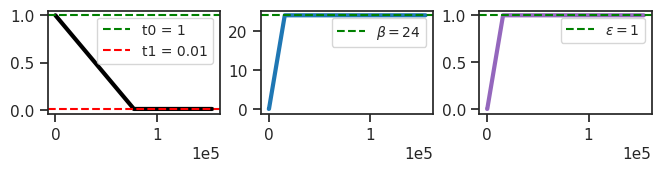

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
tr.print()
tr.show_schedules()

In [5]:
# cm = ''
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 300, avg loss: 364.155: 100%|███████| 300/300 [1:38:23<00:00, 19.68s/it]


epoch # 300, avg loss: 260.828: 100%|███████| 300/300 [1:41:28<00:00, 20.29s/it]


In [6]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.1762], device='cuda:0', grad_fn=<ExpBackward0>),)

In [7]:
print(tr.model.layer.n_exp)

tensor([30, 39, 49, 60, 70, 79, 86, 90, 92, 94, 95, 95, 95, 96, 96, 96],
       device='cuda:0', dtype=torch.int32)

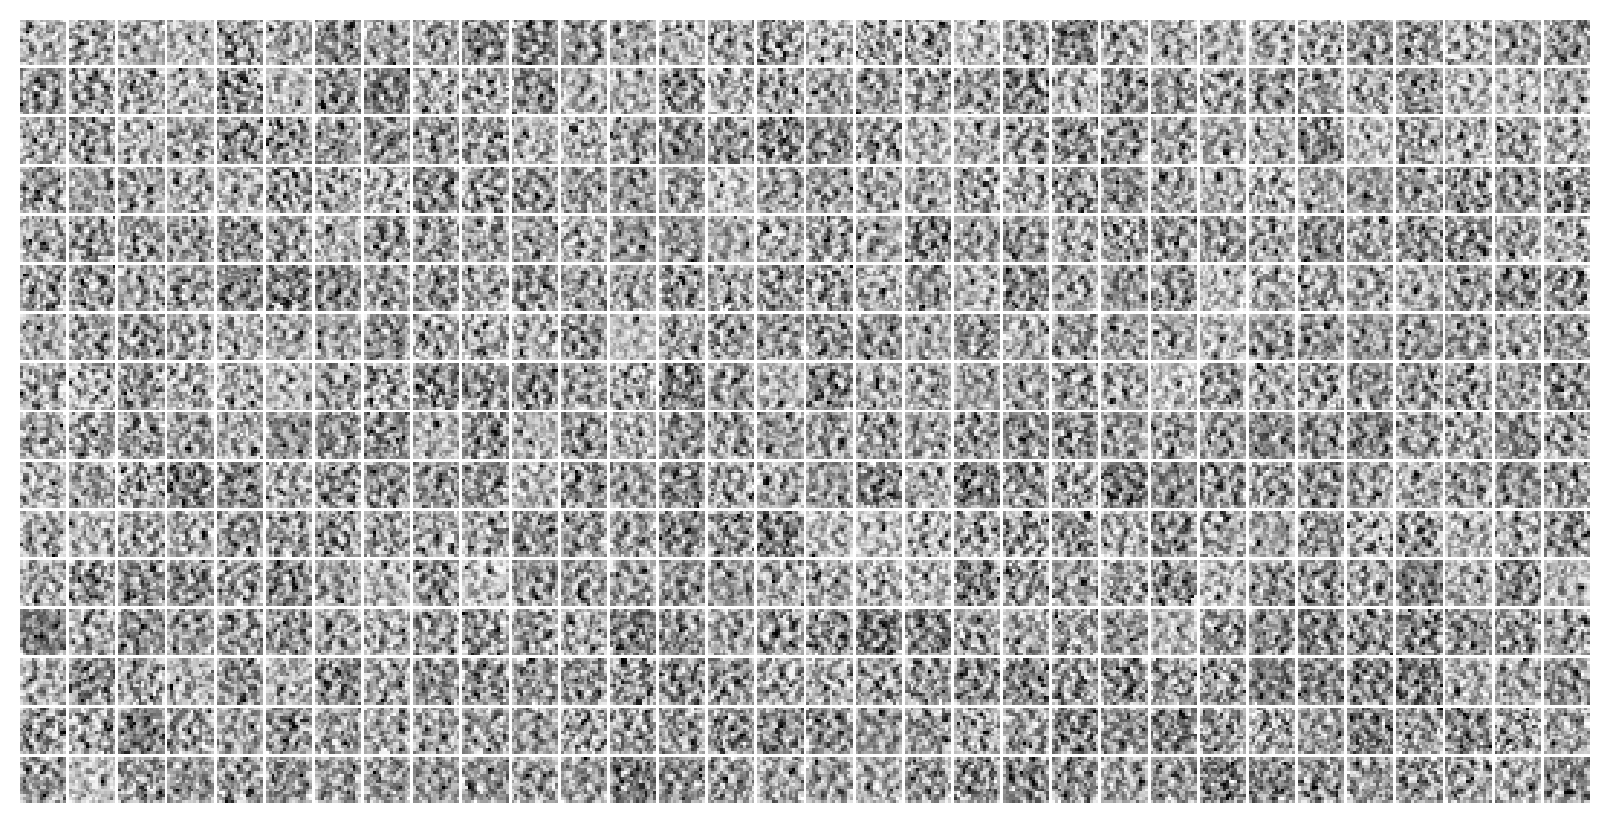

In [6]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

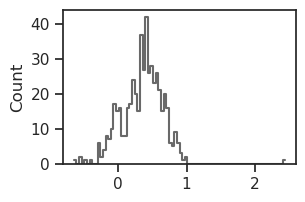

In [9]:
histplot(u0, bins=80, color='dimgrey');

In [10]:
bias = tonp(tr.model.layer.log_bias.squeeze().exp())

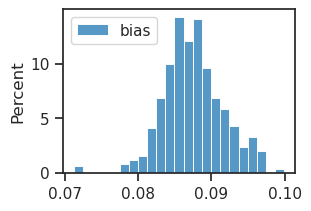

In [11]:
fig, ax = create_figure()

sns.histplot(bias, label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

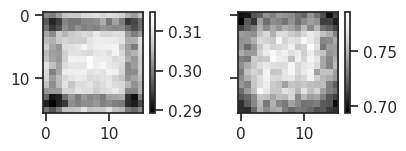

In [12]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [00:39<00:00, 19.77s/it]


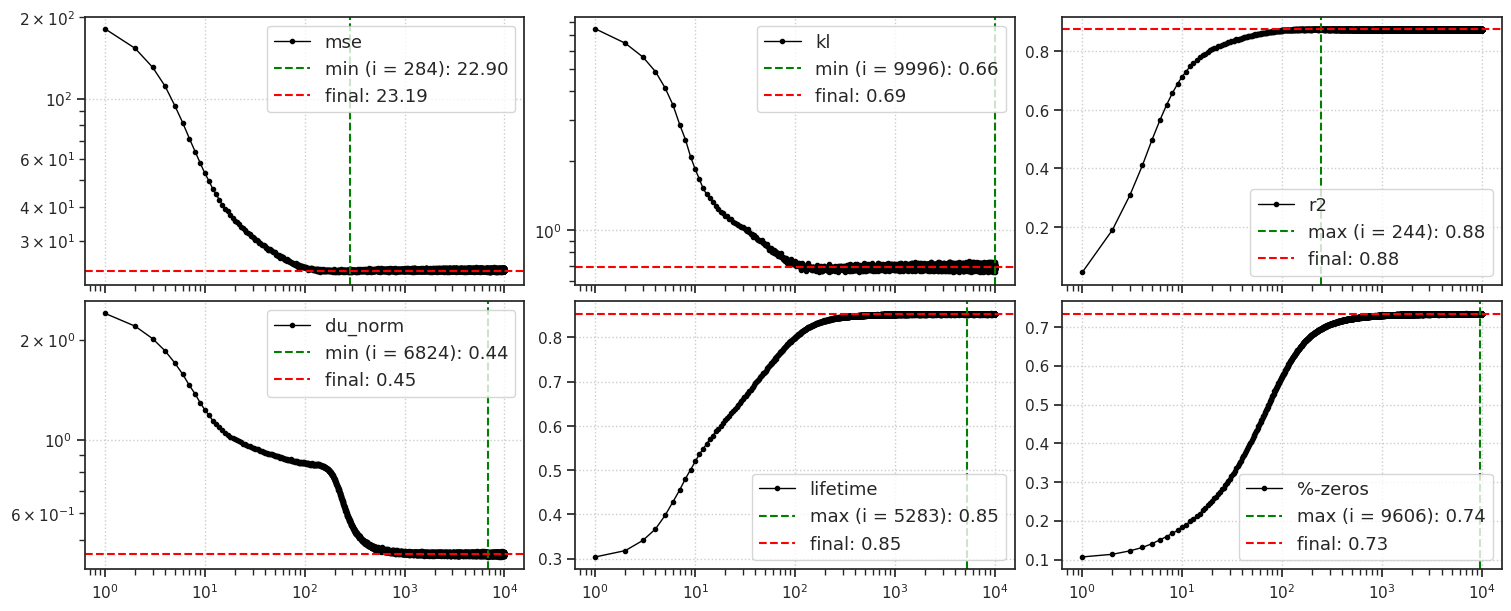

CPU times: user 50.3 s, sys: 3.05 s, total: 53.4 s
Wall time: 53.4 s


In [13]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

## Normal gold standard

Was obtained with ```loss_per_dim = False```

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs(model_type, 'vH16', 'grad|lin')

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 16.0

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.3 K   |
|     ———     |    ———     |
|    layer    |  132.3 K   |
+-------------+------------+

poisson_vH16_t-16_z-[512]_cl-10,10_<grad|lin>
b200-ep300-lr(0.002)_beta(16:0.1)_temp(0.01:0.5)_gr(500)_(2025_03_01,23:28)

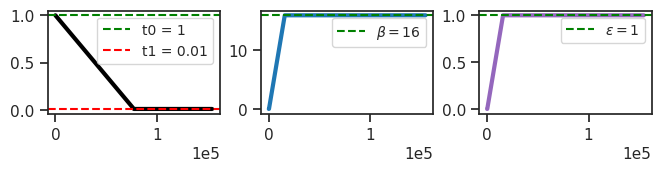

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

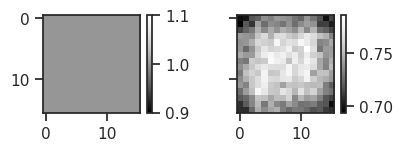

In [5]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

In [6]:
print(tr.model.layer)
print(tr.model.layer.n_exp)

PoissonLayer(input_dim=256, latent_dim=512, temperature=1, beta_inner=1, eps=1)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:0', dtype=torch.int32)

In [7]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>),)

In [8]:
tr.train()

epoch # 300, avg loss: 260.491: 100%|███████| 300/300 [1:42:55<00:00, 20.58s/it]


epoch # 300, avg loss: 260.490807: 100%|████| 300/300 [2:13:28<00:00, 26.70s/it]


In [9]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.2240], device='cuda:0', grad_fn=<ExpBackward0>),)

In [10]:
print(tr.model.layer.n_exp)

tensor([19, 29, 42, 57, 70, 78, 83, 86, 87, 87, 87, 87, 87, 88, 87, 88],
       device='cuda:0', dtype=torch.int32)

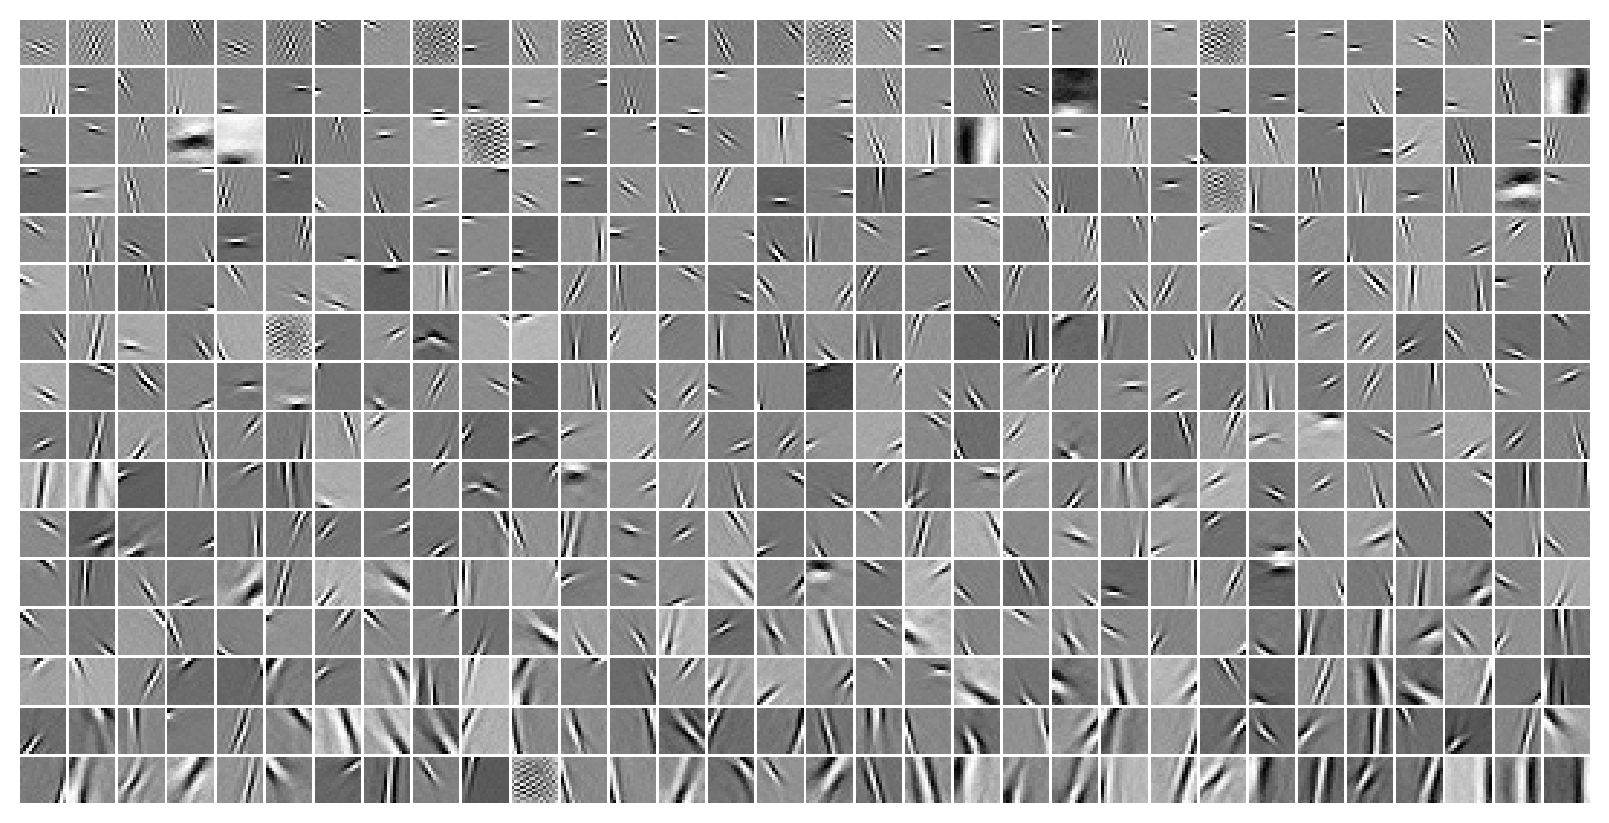

In [11]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

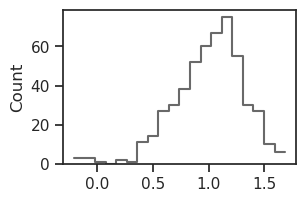

In [12]:
histplot(u0, color='dimgrey');

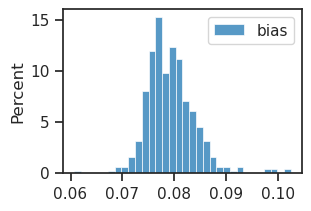

In [13]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

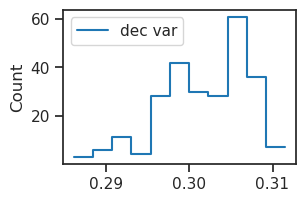

In [14]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
histplot(np.exp(log_scale) ** 2, label='dec var')
plt.legend()
plt.show()

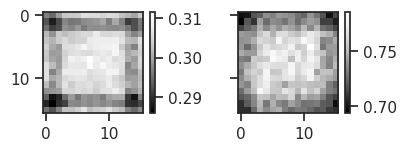

In [15]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [00:38<00:00, 19.47s/it]


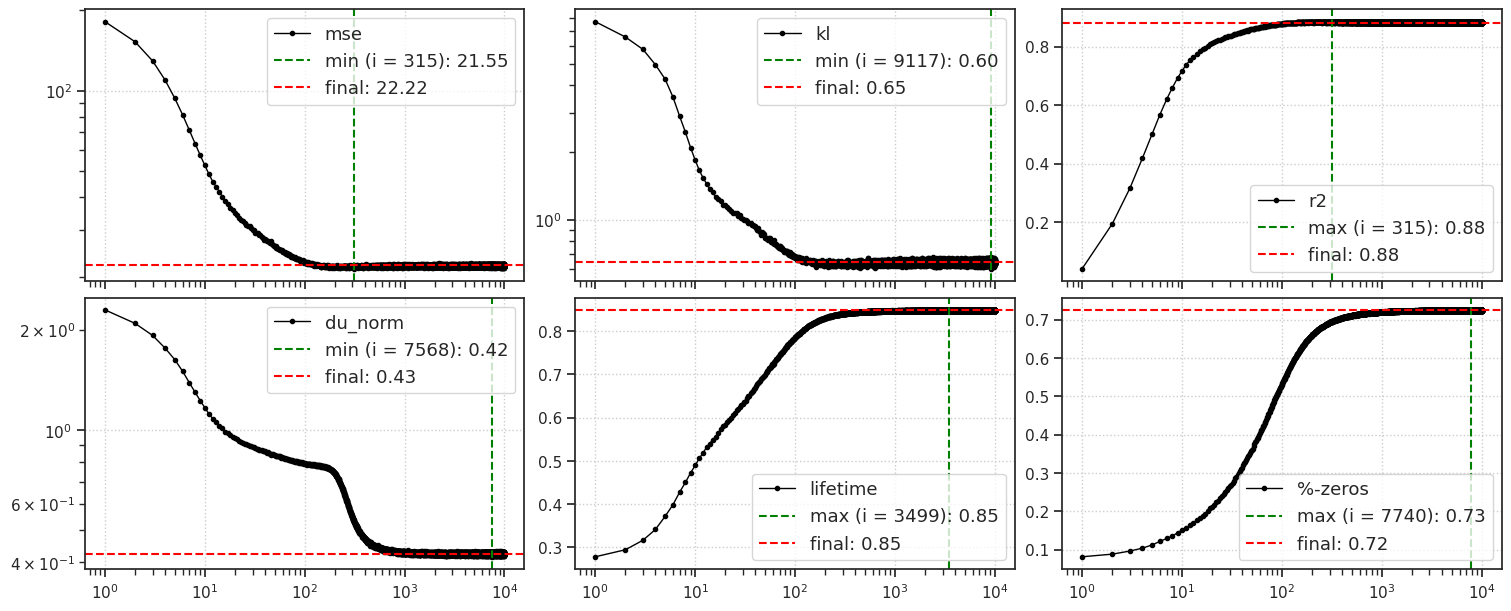

CPU times: user 47.4 s, sys: 2.5 s, total: 49.9 s
Wall time: 49.9 s


In [16]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

100%|███████████████████████████████████| 2/2 [00:42<00:00, 21.37s/it]


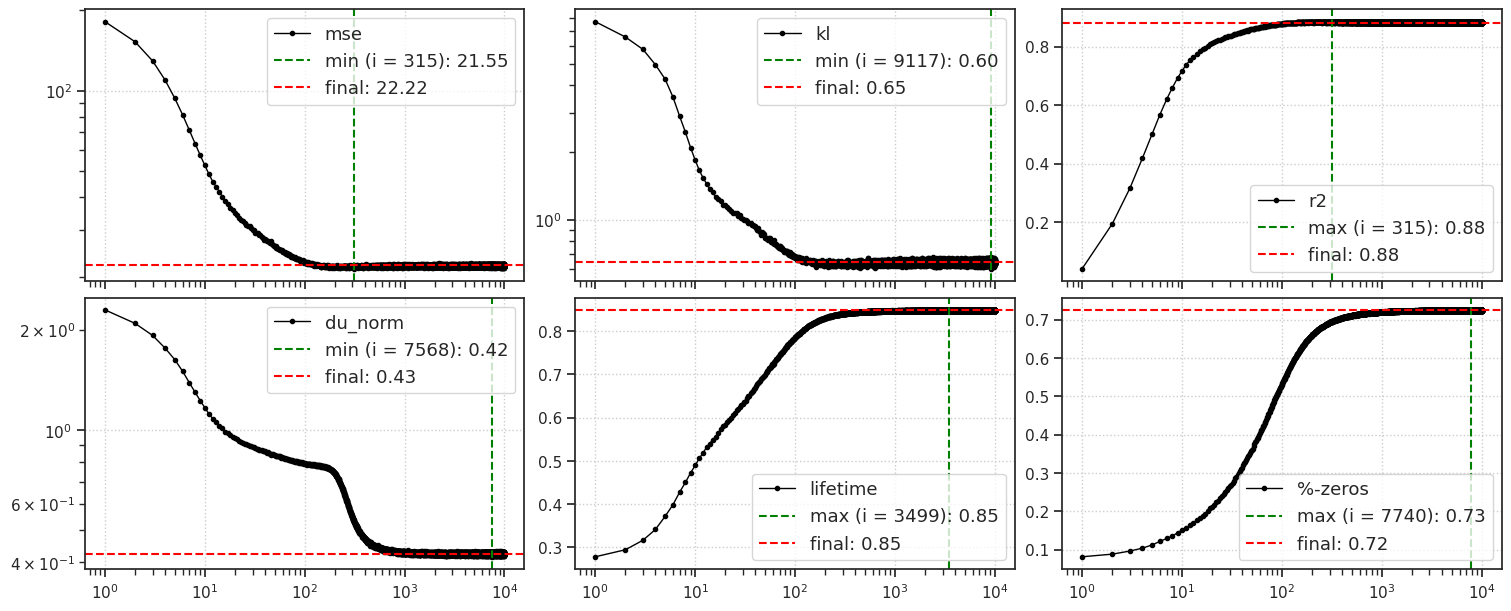

CPU times: user 51.3 s, sys: 2.58 s, total: 53.9 s
Wall time: 53.9 s


In [16]:
### Was: (not) loss per dim

In [19]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=['u', 'v', 'conditional'],
).stack()

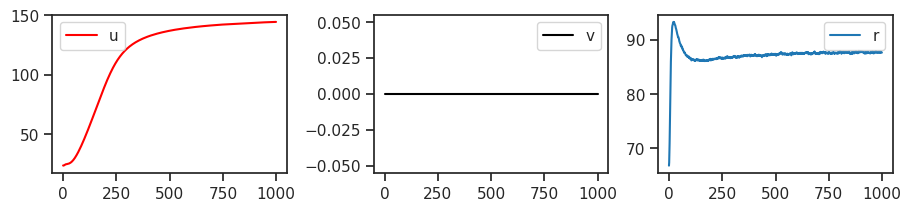

In [20]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

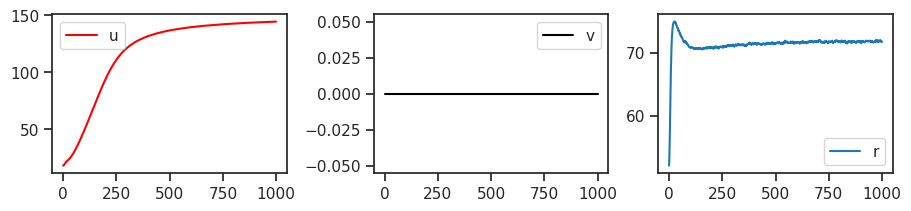

In [17]:
### Was: beta = 20.0

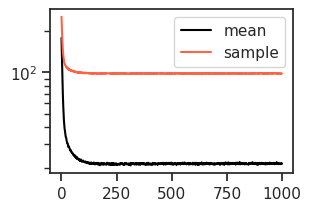

(tensor([21.6160, 21.8161, 21.6817, 21.5563, 21.7669], device='cuda:0'),
 tensor([98.4087, 98.8584, 98.3608, 98.3350, 98.3148], device='cuda:0'))

In [21]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)

samples = torch.stack([
    p.sample() for p in
    output['conditional'].values()
], dim=1)

mse_locs = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
mse_samples = (samples - feeder[0].unsqueeze(1)).pow(2).sum(-1)

fig, ax = create_figure()
ax.plot(tonp(mse_locs.mean(0)), color='k', label='mean')
ax.plot(tonp(mse_samples.mean(0)), color='tomato', label='sample')
ax.set_yscale('log')
add_legend(ax)
plt.show()

mse_locs.mean(0)[-5:], mse_samples.mean(0)[-5:]

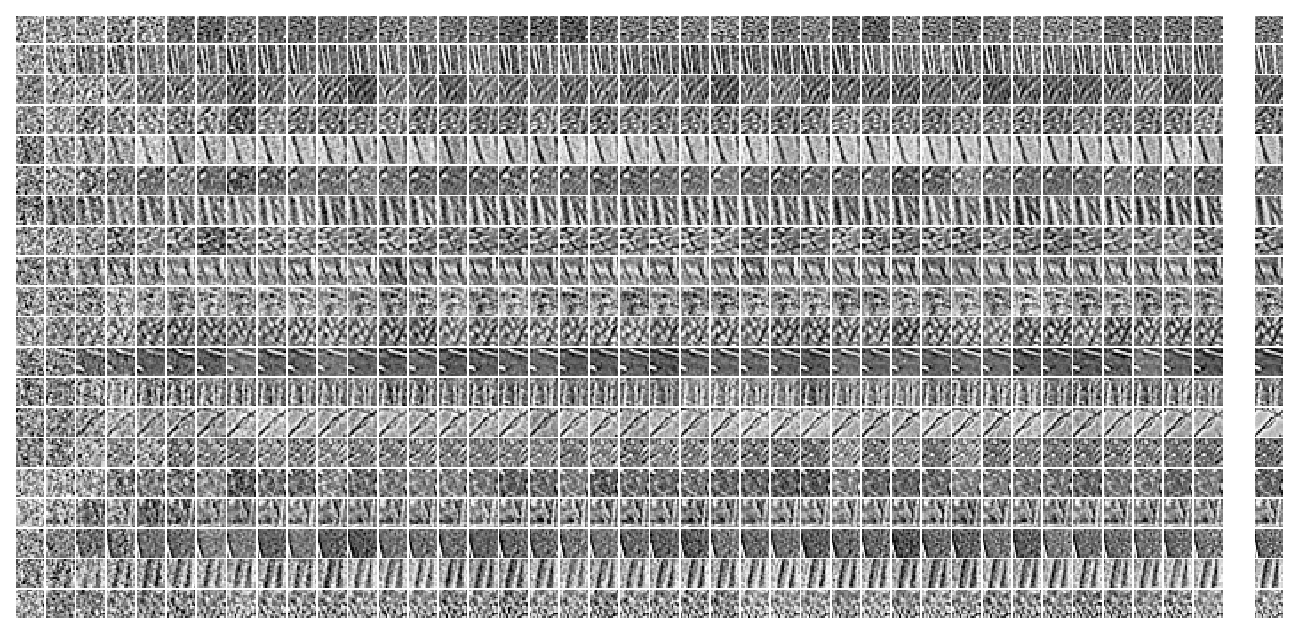

In [22]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

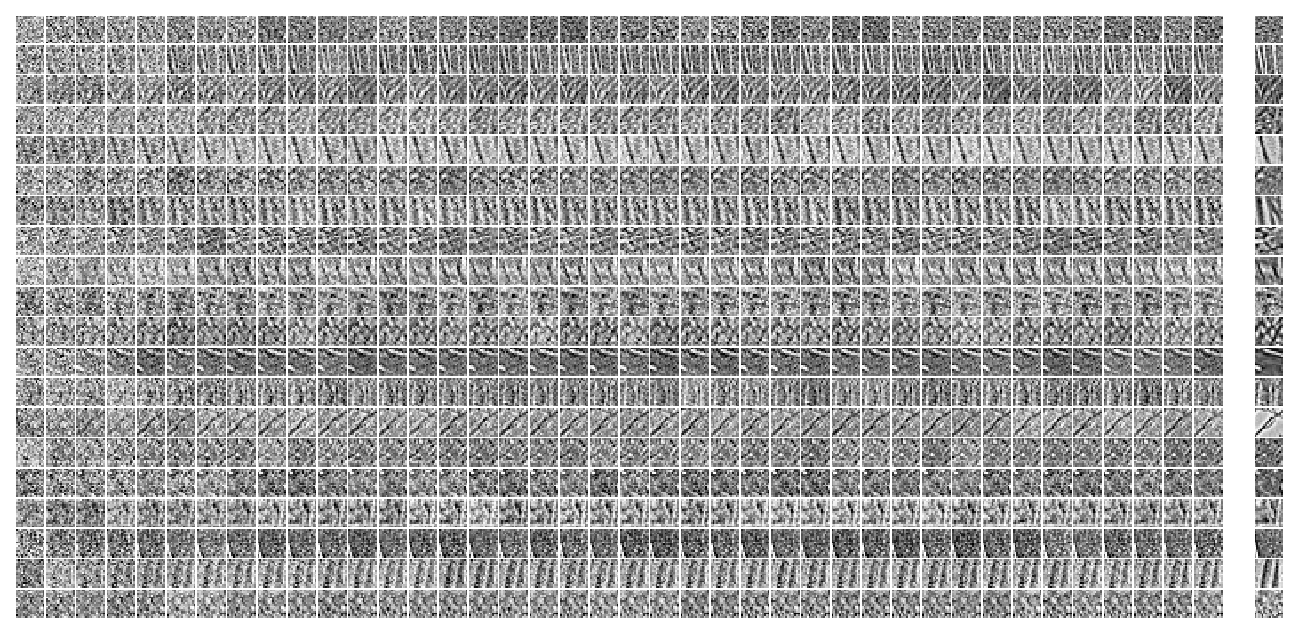

In [23]:
x2p = tonp(samples)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

## Try with MSE

In [6]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs(model_type, 'vH16-wht', 'ngd|lin')

cfg_vae['t_train'] = 16
cfg_vae['beta_outer'] = 24.0

cfg_vae['track_stats'] = True

cfg_vae['recon_mode'] = 'mse'
cfg_vae['fit_sigma'] = False

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.1 K   |
|     ———     |    ———     |
|    layer    |  132.1 K   |
+-------------+------------+

poisson_vH16-wht_t-16_b-24_k-[512]_u-10,du-10
b200-ep300-lr(0.005)_temp(0.01:0.5)_gr(300)_(2025_05_21,13:12)

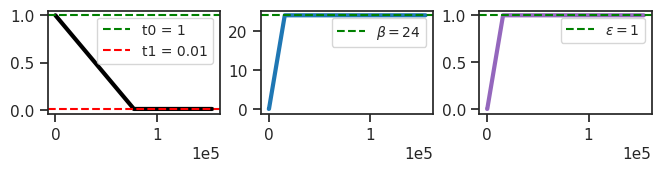

In [7]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
tr.print()
tr.show_schedules()

In [8]:
# cm = ''
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 300, avg loss: 206.615: 100%|███████| 300/300 [1:34:02<00:00, 18.81s/it]


epoch # 300, avg loss: 318.562: 100%|███████| 300/300 [1:43:23<00:00, 20.68s/it]


epoch # 300, avg loss: 260.828: 100%|███████| 300/300 [1:41:28<00:00, 20.29s/it]


In [9]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

AttributeError: 'PoissonLayer' object has no attribute 'log_lr'

In [10]:
print(tr.model.layer.n_exp)

tensor([12, 15, 20, 25, 31, 36, 41, 46, 49, 51, 53, 54, 55, 56, 56, 56],
       device='cuda:0', dtype=torch.int32)

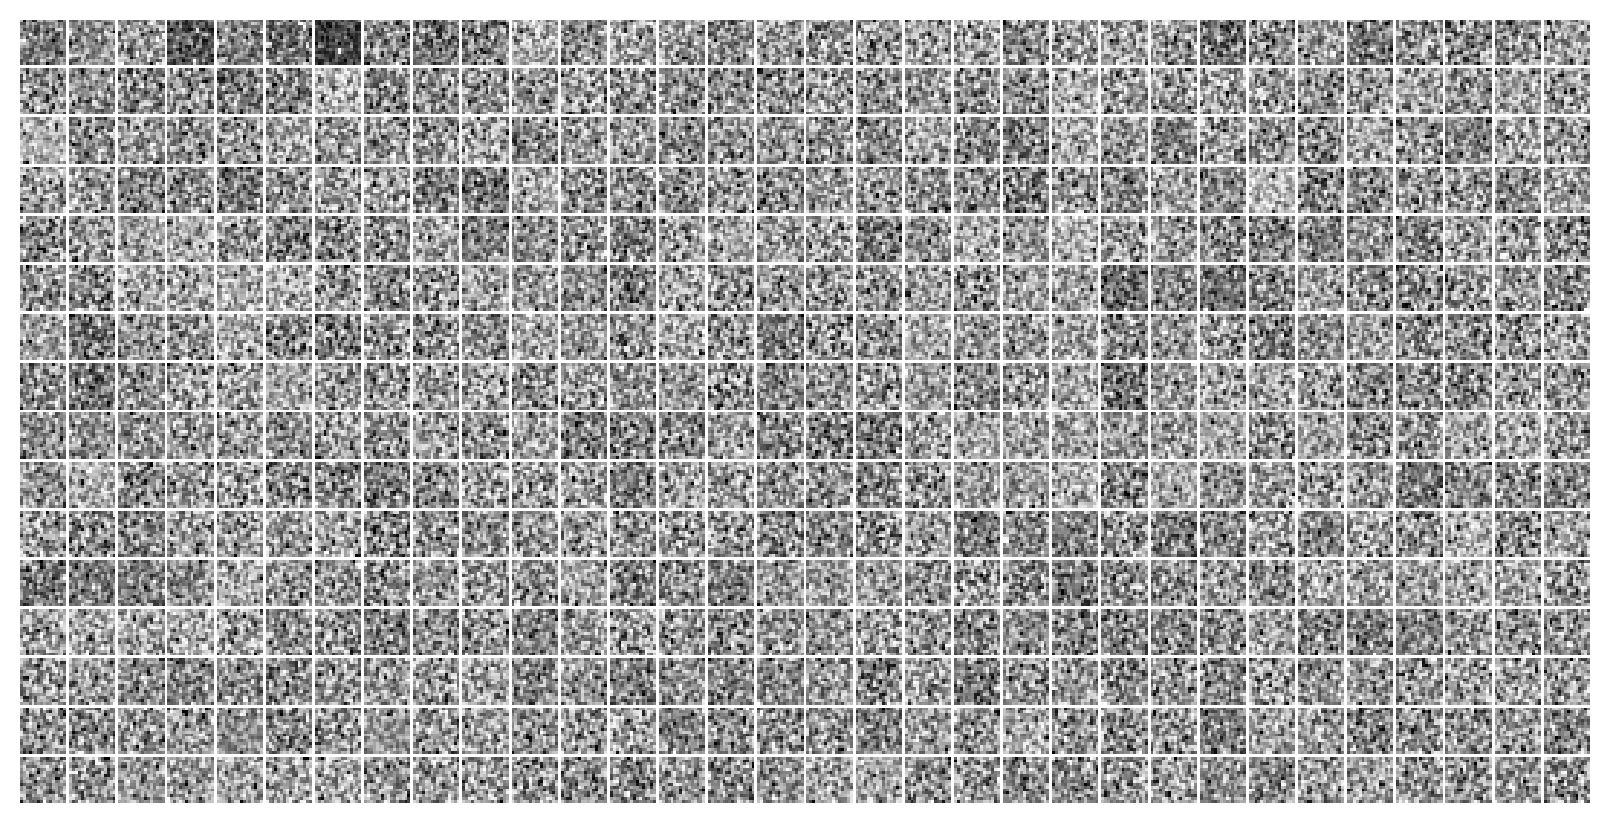

In [21]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

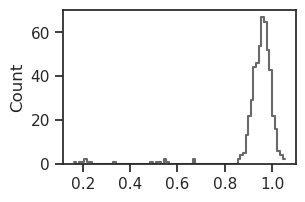

In [22]:
histplot(u0, bins=80, color='dimgrey');

100%|███████████████████████████████████| 2/2 [00:04<00:00,  2.18s/it]


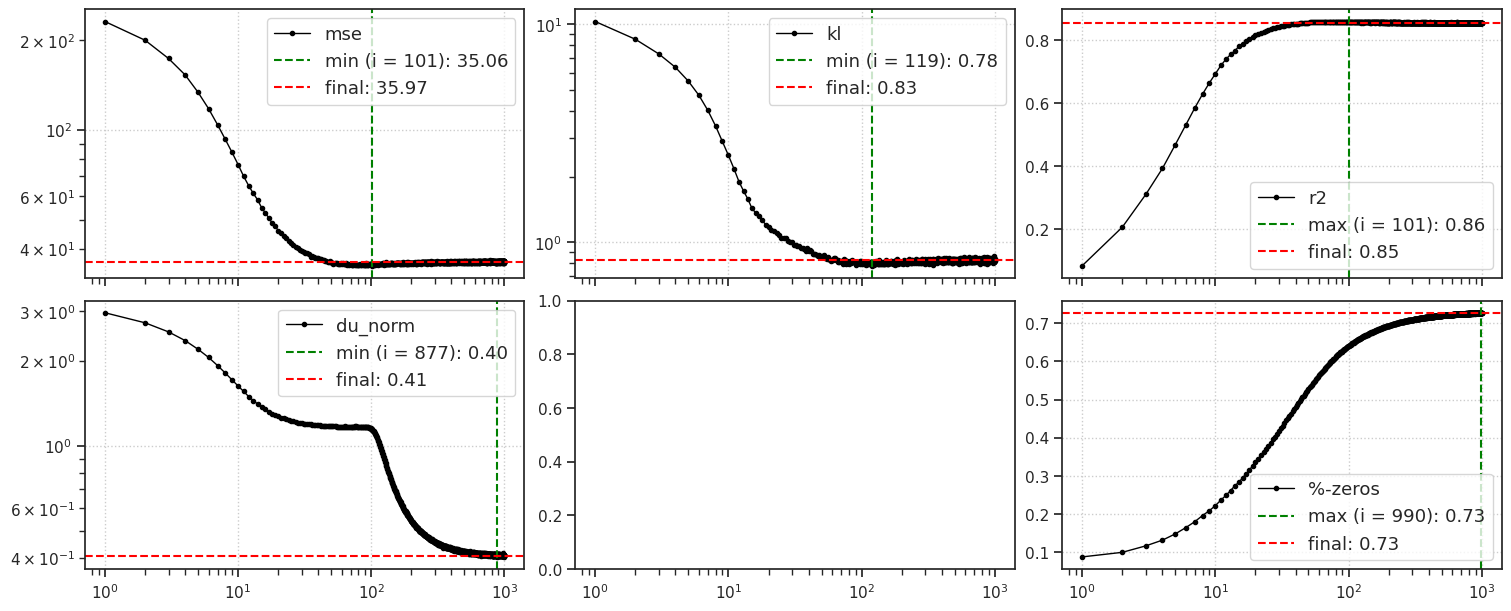

CPU times: user 6.93 s, sys: 140 ms, total: 7.07 s
Wall time: 7.07 s


In [23]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [14]:
self = tr.model.layer

In [15]:
dec_log_sigma = self.get_dec_log_sigma()
dec_var = torch.exp(2.0 * dec_log_sigma)

In [20]:
collections.Counter(list(tonp(dec_var.ravel())))

Counter({1.0: 256})